# Introduction to Seaborn — Full Solved Notebook

This notebook introduces **Seaborn**, a Python library used for statistical data visualization.

Each task is written as a clear **request** in markdown, followed by a complete solution and a short explanation when needed.

We will use a restaurant `tips`-style dataset with columns such as:

- `total_bill`
- `tip`
- `sex`
- `smoker`
- `day`
- `time`
- `size`

> Note: The notebook first tries to load Seaborn's built-in `tips` dataset. If internet access is not available, it creates a similar sample dataset automatically.

## 1. Import libraries

**Request:** Import the libraries needed for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Load the dataset

**Request:** Load the `tips` dataset.

In [2]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 3. Basic dataset exploration

**Request:** Check the first rows, shape, column names, data types, and missing values.

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:")
print(df.dtypes)
print("Missing values:")
print(df.isna().sum())

Shape: (244, 7)
Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
Data types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
Missing values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## 4. Summary statistics

**Request:** Show summary statistics for numerical columns and count unique values for categorical columns.

In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [10]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(f"{col} value counts:")
    print(df[col].value_counts())
    print()

sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64

smoker value counts:
smoker
No     151
Yes     93
Name: count, dtype: int64

day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

time value counts:
time
Dinner    176
Lunch      68
Name: count, dtype: int64



# Distribution Plots

Distribution plots help us understand how values are spread.

Common questions:

- Are most bills small or large?
- Are tips normally distributed?
- Are there outliers?
- Do smokers and non-smokers have different bill distributions?

## 5. Histogram with `histplot`

**Request:** Plot the distribution of `total_bill` using a histogram.

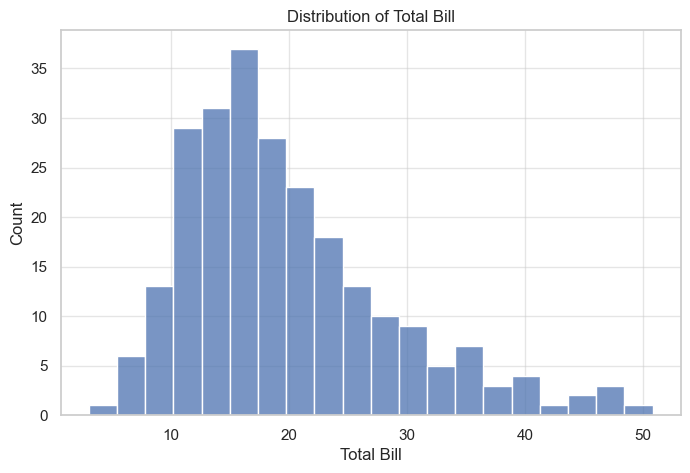

In [11]:
plt.figure(figsize=(8, 5))     #just for controlling figure size
sns.histplot(data=df, x="total_bill", bins=20)
plt.title("Distribution of Total Bill")    #giving title
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()


<Axes: xlabel='total_bill', ylabel='Count'>

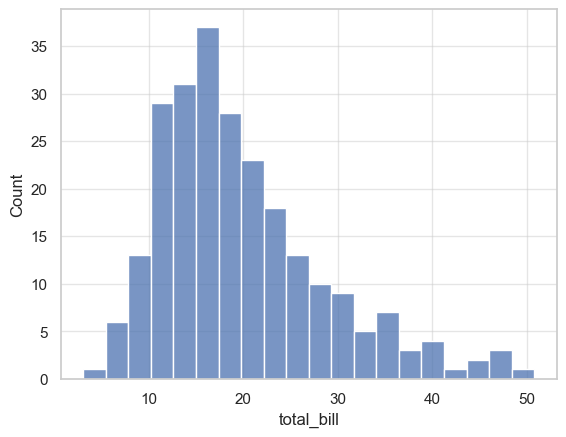

In [12]:
# or simply like this

sns.histplot(data=df, x="total_bill", bins=20)

**Explanation:**  
A histogram groups numerical values into bins. It shows where most values are concentrated.

## 6. Histogram with KDE curve

**Request:** Plot the distribution of `tip` and add a smooth KDE curve.

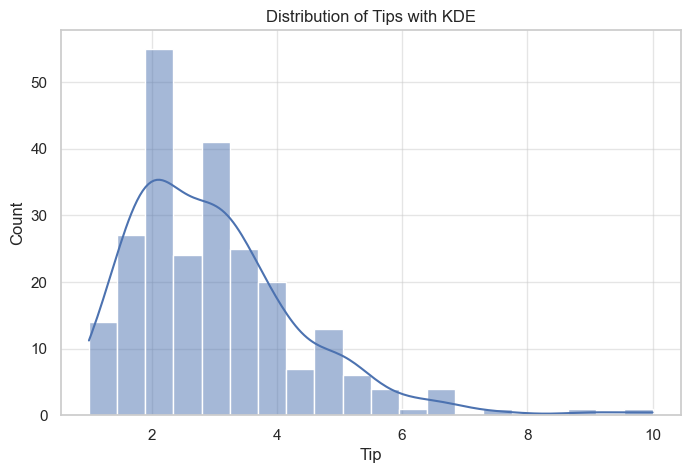

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tip", bins=20, kde=True)
plt.title("Distribution of Tips with KDE")
plt.xlabel("Tip")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='tip', ylabel='Count'>

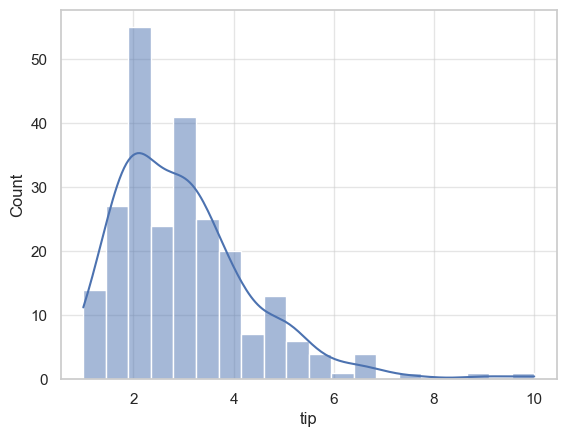

In [15]:
# or simply without formating image

sns.histplot(data=df, x="tip", bins=20, kde=True)


**Explanation:**  
`kde=True` adds a smooth density curve. It helps us see the general shape of the distribution.

## 7. Compare distributions using `hue`

**Request:** Compare the distribution of `total_bill` between smokers and non-smokers.

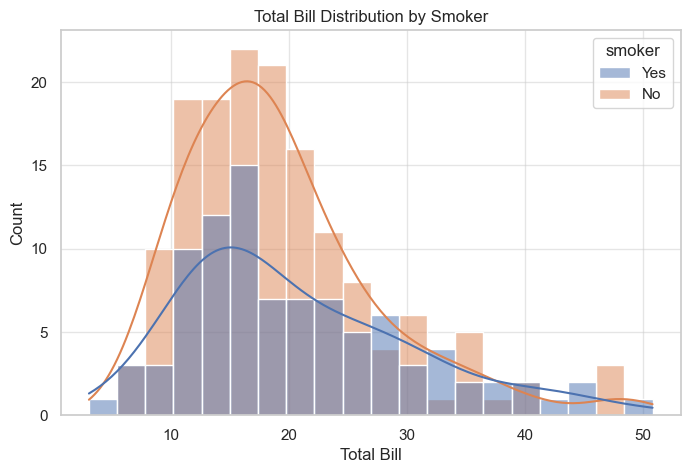

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="total_bill", hue="smoker", bins=20, kde=True)
plt.title("Total Bill Distribution by Smoker")
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()

## 8. Separate histograms with `displot`

**Request:** Create separate histograms of `total_bill` for each value of `smoker`.

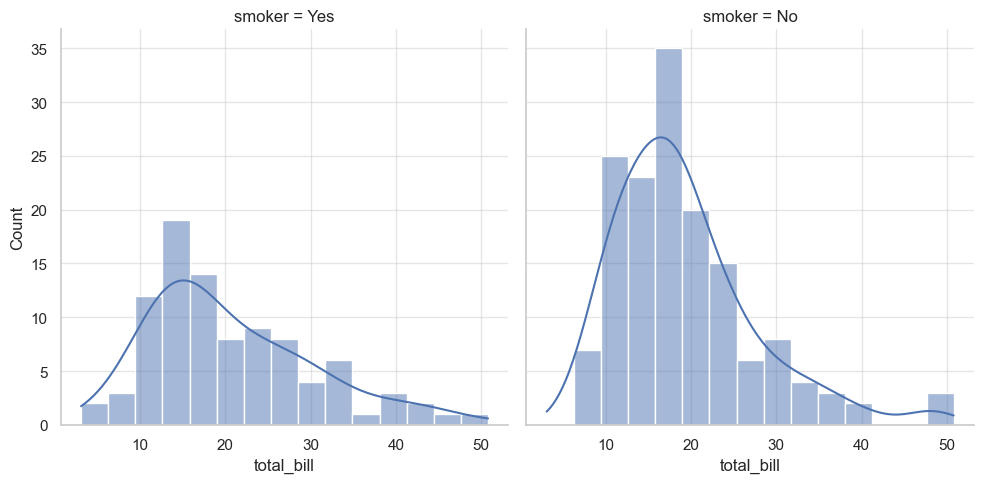

In [18]:
sns.displot(data=df, x="total_bill", col="smoker", bins=15, kde=True)
plt.show()

**Explanation:**  
`displot` is a figure-level function. It can easily create separate plots using `col`, `row`, or `hue`.

# Relationship Plots

Relationship plots are used when we want to compare two numerical variables.

## 9. Scatter plot

**Request:** Show the relationship between `total_bill` and `tip`.

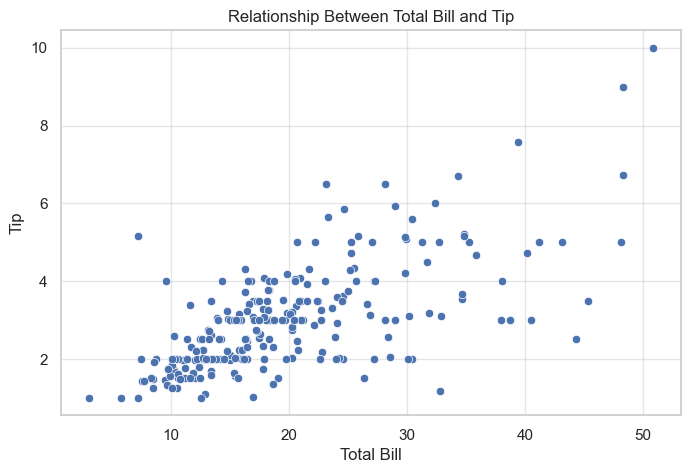

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Relationship Between Total Bill and Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

**Explanation:**  
Each dot represents one row. This plot helps us see whether bigger bills usually have bigger tips.

## 10. Scatter plot with color and size

**Request:** Use color to separate smokers and marker size to show table size.

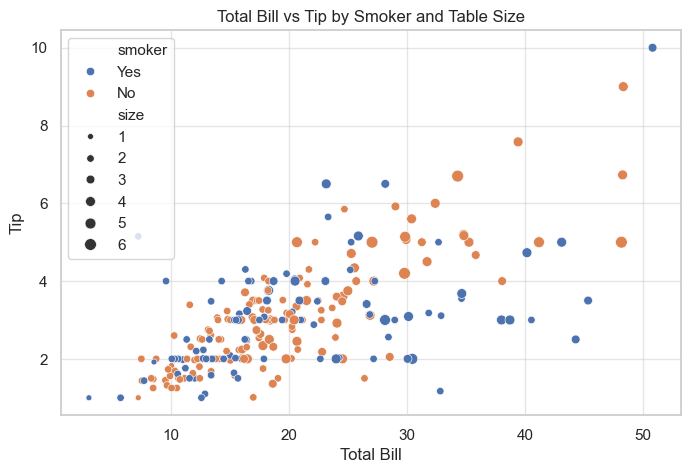

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="smoker", size="size")
plt.title("Total Bill vs Tip by Smoker and Table Size")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

## 11. Regression plot

**Request:** Add a regression line to show the trend between `total_bill` and `tip`.

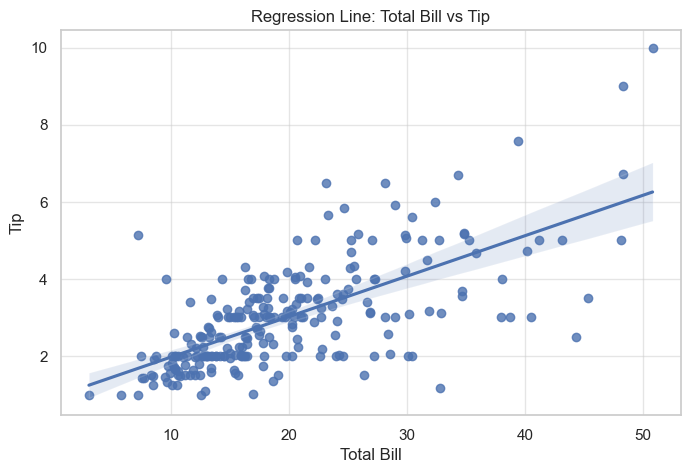

In [22]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="total_bill", y="tip")
plt.title("Regression Line: Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

**Explanation:**  
`regplot` adds a trend line. It is useful when we want to see whether a relationship is positive, negative, or weak.

## 12. Joint plot

**Request:** Create a `jointplot` for `total_bill` and `tip`. Use `kind="hex"`.

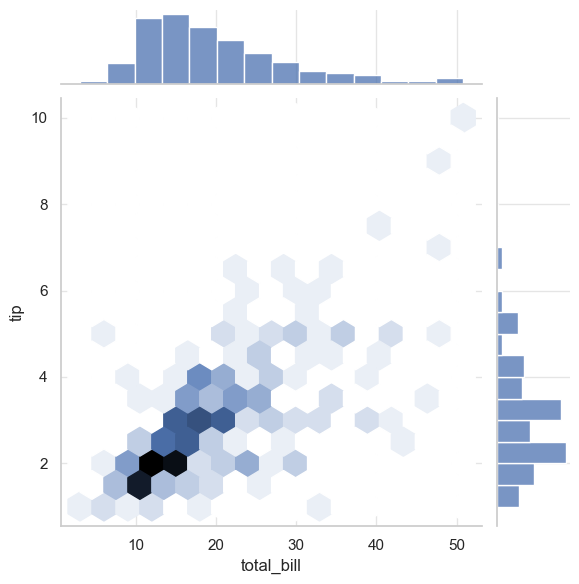

In [23]:
sns.jointplot(data=df, x="total_bill", y="tip", kind="hex", height=6)
plt.show()

**Explanation:**  
`jointplot` combines a relationship plot with distributions on the sides. `kind="hex"` is useful when many points overlap.

**Explanation:**
`jointplot` used with `kind="scatter"` will give same result as sns.scatterplot()

# Categorical Plots

Categorical plots are useful when one variable is a category, such as `day`, `sex`, `smoker`, or `time`.

## 13. Count plot

**Request:** Count how many records exist for each day.

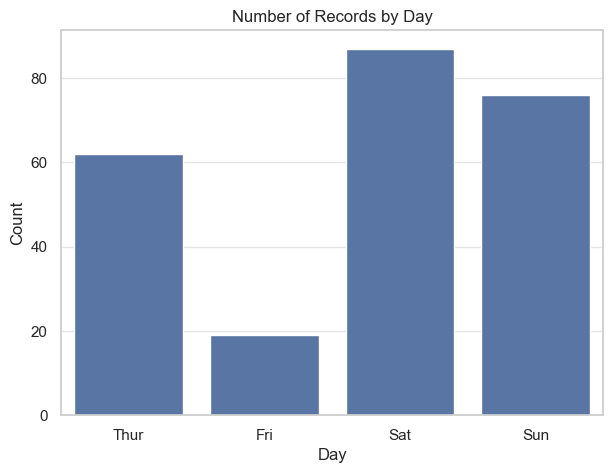

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="day")
plt.title("Number of Records by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

**Explanation:**  
`countplot` counts rows in each category. It does not need a `y` column.

## 14. Count plot with hue

**Request:** Count records by day and separate them by `time`.

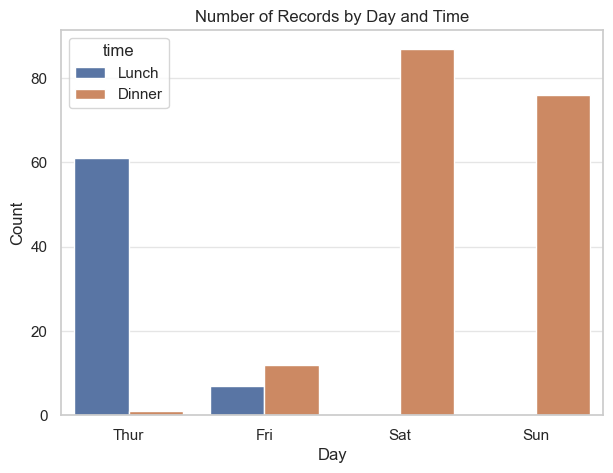

In [25]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="day", hue="time")
plt.title("Number of Records by Day and Time")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

## 15. Bar plot for averages

**Request:** Show the average `total_bill` for each day.

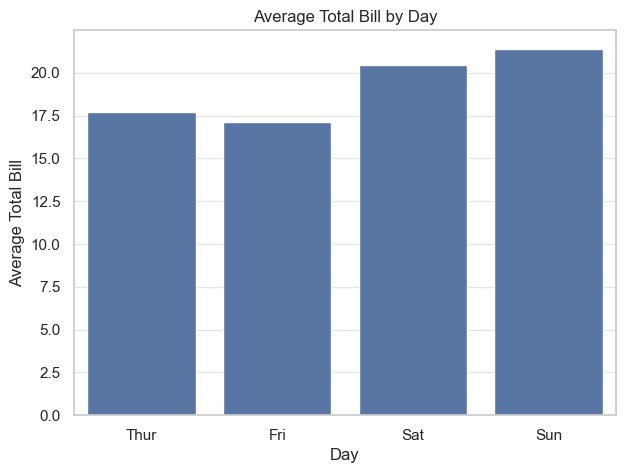

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


In [26]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="day", y="total_bill", estimator="mean", errorbar=None)
plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()

# Pandas check
print(df.groupby("day")["total_bill"].mean())

**Explanation:**  
`barplot` calculates an aggregate value. By default, it shows the mean. Here we explicitly used `estimator="mean"`.

## 16. Bar plot for total sum

**Request:** Show the total bill amount collected for each day.

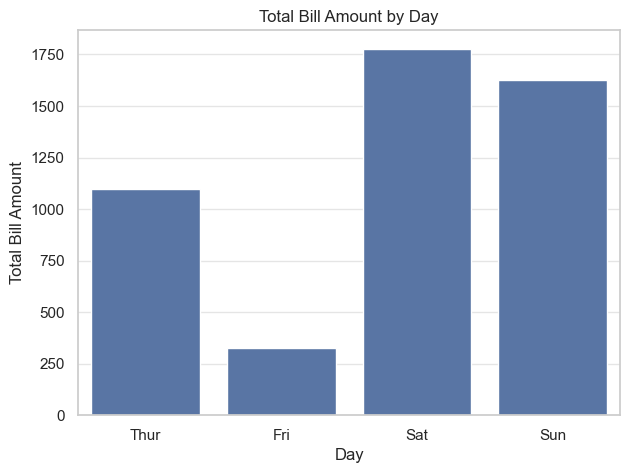

day
Thur    1096.33
Fri      325.88
Sat     1778.40
Sun     1627.16
Name: total_bill, dtype: float64


In [27]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="day", y="total_bill", estimator="sum", errorbar=None)
plt.title("Total Bill Amount by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill Amount")
plt.show()

# Pandas check
print(df.groupby("day")["total_bill"].sum())

## 17. Box plot

**Request:** Use a box plot to compare `total_bill` distribution across days.

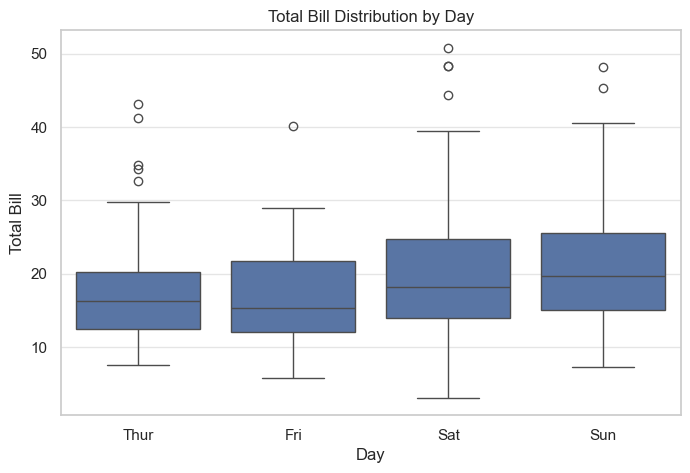

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day", y="total_bill")
plt.title("Total Bill Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

**Explanation:**  
A box plot shows median, quartiles, spread, and possible outliers. It is very useful for comparing distributions between categories.

## 18. Box plot with hue

**Request:** Compare `total_bill` by day and separate results by smoker status.

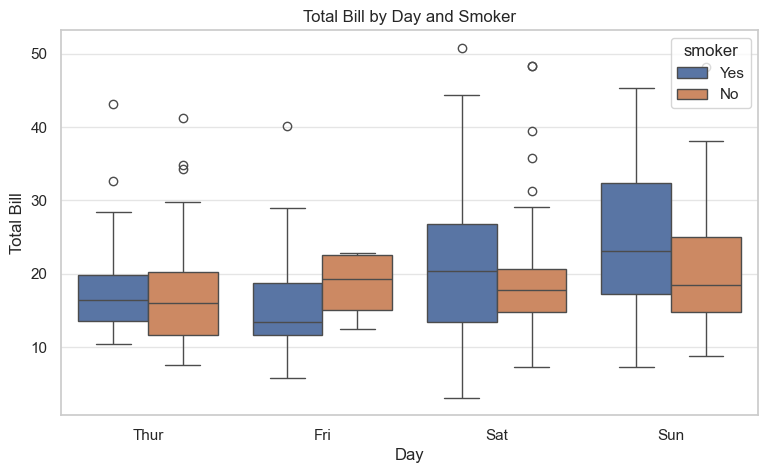

In [29]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="day", y="total_bill", hue="smoker")
plt.title("Total Bill by Day and Smoker")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

## 20. Strip plot

**Request:** Show individual `total_bill` values for each day using `stripplot`.

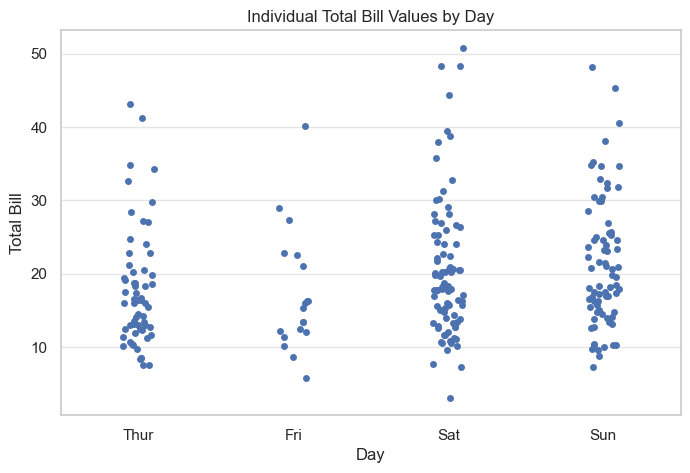

In [31]:
plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x="day", y="total_bill", jitter=True)
plt.title("Individual Total Bill Values by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

**Explanation:**  
`stripplot` shows each observation. `jitter=True` spreads points slightly so they are easier to see.

## 21. Swarm plot

**Request:** Use `swarmplot` to show individual `tip` values by day without point overlap.

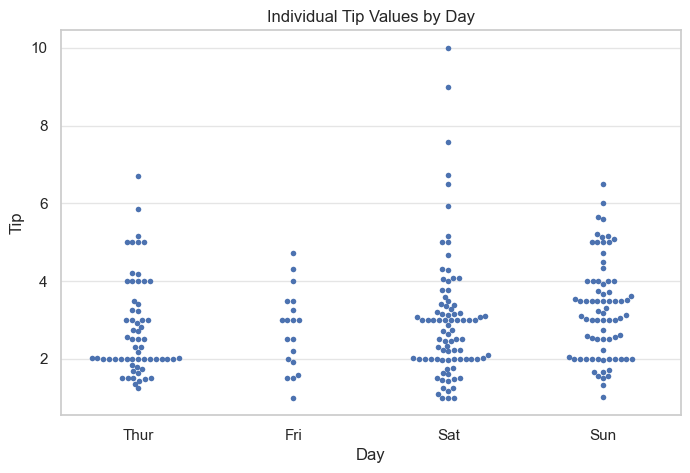

In [32]:
plt.figure(figsize=(8, 5))
sns.swarmplot(data=df, x="day", y="tip", size=4)
plt.title("Individual Tip Values by Day")
plt.xlabel("Day")
plt.ylabel("Tip")
plt.show()

**Explanation:**  
`swarmplot` also shows individual observations, but it tries to avoid overlapping points. It can be slower for large datasets.

# Pair Plots and Grids

## 22. Pair plot

**Request:** Create a pair plot for all numerical columns and color by `smoker`.

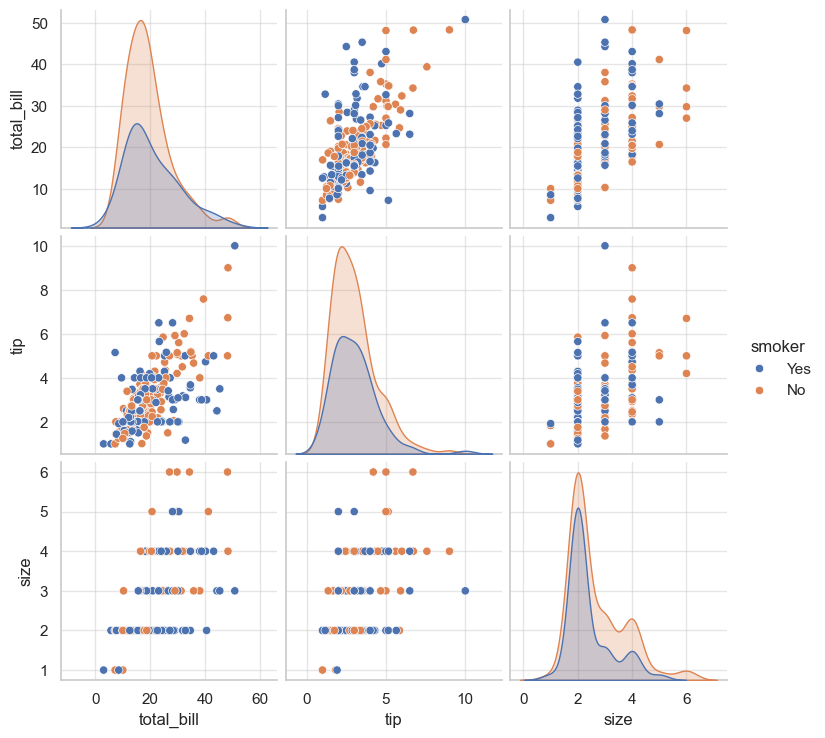

In [33]:
sns.pairplot(data=df, hue="smoker")
plt.show()

**Explanation:**  
`pairplot` automatically plots relationships between numerical columns. It is useful for quick exploratory analysis.

## 23. PairGrid

**Request:** Create a custom `PairGrid` where diagonal plots are histograms and off-diagonal plots are scatter plots.

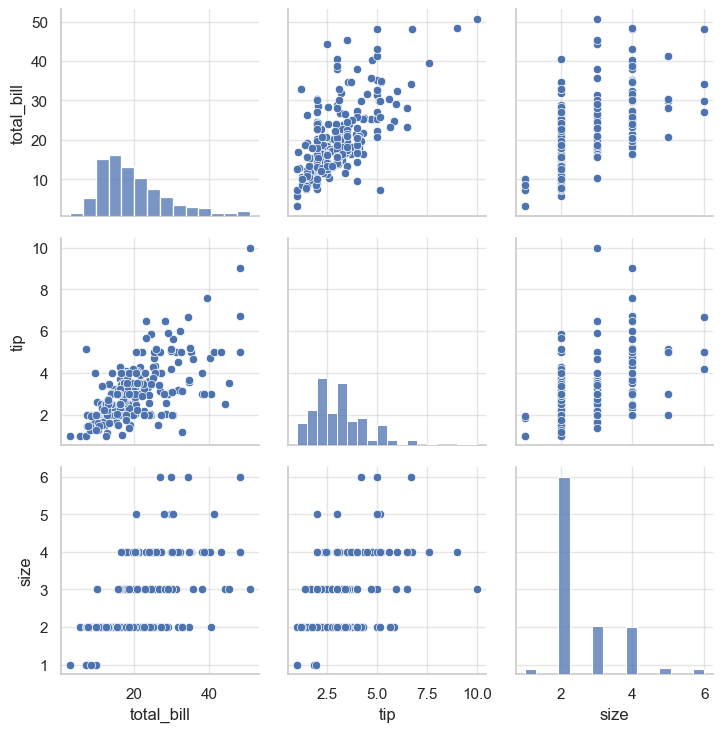

In [34]:
numeric_df = df[["total_bill", "tip", "size"]]

g = sns.PairGrid(numeric_df)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
plt.show()

**Explanation:**  
`PairGrid` gives more manual control than `pairplot`. It is useful when we want different plot types in different grid positions.

# Matrix Plots

## 24. Correlation matrix

**Request:** Calculate the correlation matrix for numerical columns.

In [35]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


## 25. Heatmap

**Request:** Show the correlation matrix using a heatmap with annotations.

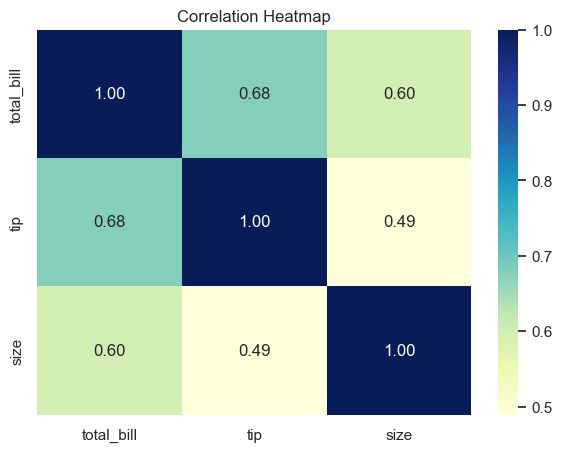

In [36]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Explanation:**  
A heatmap uses color to represent values. In correlation heatmaps, values close to `1` mean strong positive relationship, values close to `-1` mean strong negative relationship, and values close to `0` mean weak relationship.

## 26. Pivot table heatmap

**Request:** Create a pivot table of average `total_bill` by `day` and `time`, then plot it as a heatmap.

time,Lunch,Dinner
day,,
Thur,17.664754,18.780000
Fri,12.845714,19.663333
Sat,NaN,20.441379
Sun,NaN,21.410000


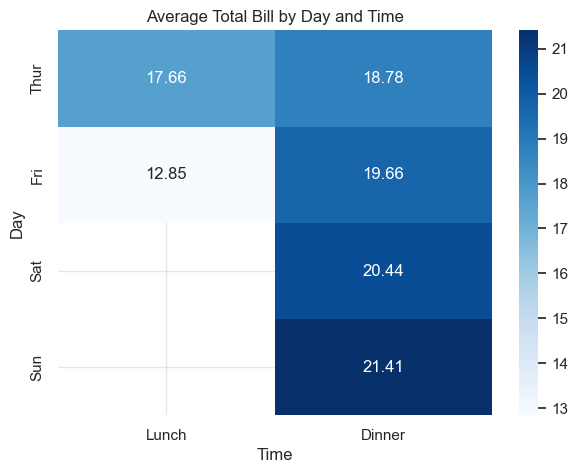

In [37]:
pivot_bill = df.pivot_table(values="total_bill", index="day", columns="time", aggfunc="mean")
display(pivot_bill)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_bill, annot=True, cmap="Blues", fmt=".2f")
plt.title("Average Total Bill by Day and Time")
plt.xlabel("Time")
plt.ylabel("Day")
plt.show()

# Styling and Figure Size

## 27. Change plot style

**Request:** Change the Seaborn style and create a count plot.

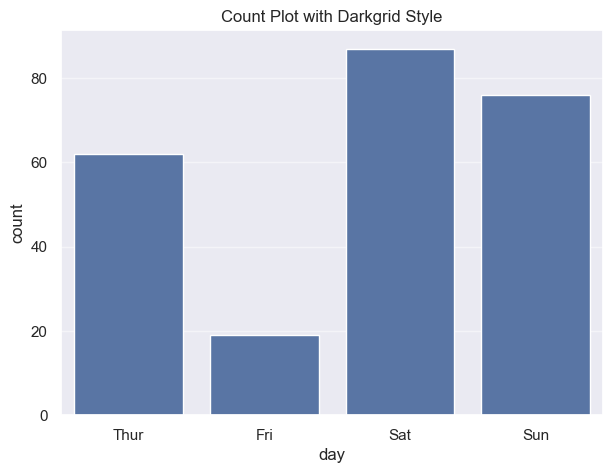

In [40]:
sns.set_style("darkgrid")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="day")
plt.title("Count Plot with Darkgrid Style")
plt.show()

# Return to default style for the rest of the notebook
sns.set_theme(style="whitegrid")

## 28. Change figure size

**Request:** Create a larger box plot for `total_bill` by day.

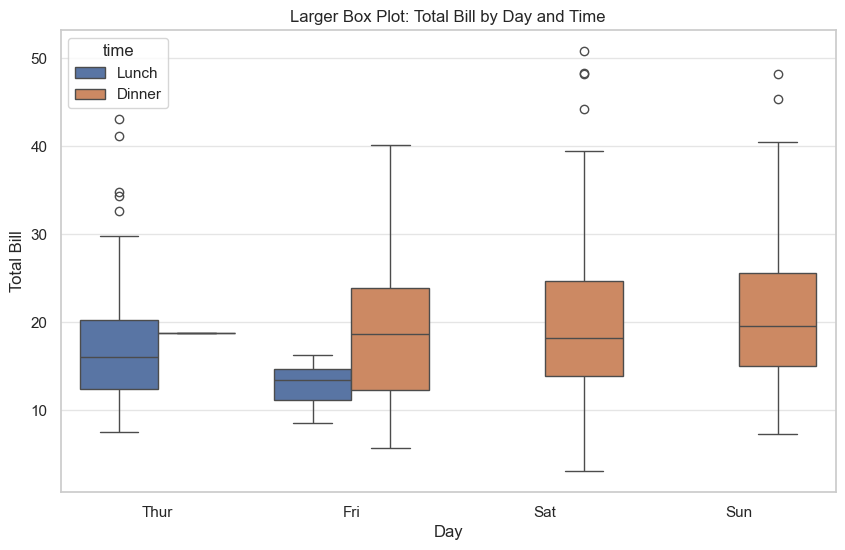

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="day", y="total_bill", hue="time")
plt.title("Larger Box Plot: Total Bill by Day and Time")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

# Mini Analysis Questions

These final tasks combine Pandas and Seaborn.

## 29. Which day has the highest average total bill?

**Request:** Use Pandas to calculate the average `total_bill` by day and visualize the result.

,day,total_bill
0,Thur,17.682742
1,Fri,17.151579
2,Sat,20.441379
3,Sun,21.410000


Highest average total bill: Sun -> 21.41


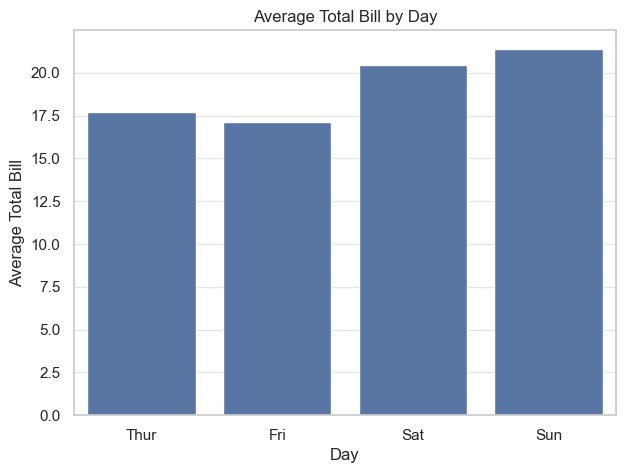

In [42]:
avg_bill_by_day = df.groupby("day", as_index=False)["total_bill"].mean()
display(avg_bill_by_day)

highest_day = avg_bill_by_day.loc[avg_bill_by_day["total_bill"].idxmax()]
print("Highest average total bill:", highest_day["day"], "->", round(highest_day["total_bill"], 2))

plt.figure(figsize=(7, 5))
sns.barplot(data=avg_bill_by_day, x="day", y="total_bill", errorbar=None)
plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()

## 30. Which day has the highest average tip?

**Request:** Calculate and plot the average `tip` by day.

,day,tip
0,Thur,2.771452
1,Fri,2.734737
2,Sat,2.993103
3,Sun,3.255132


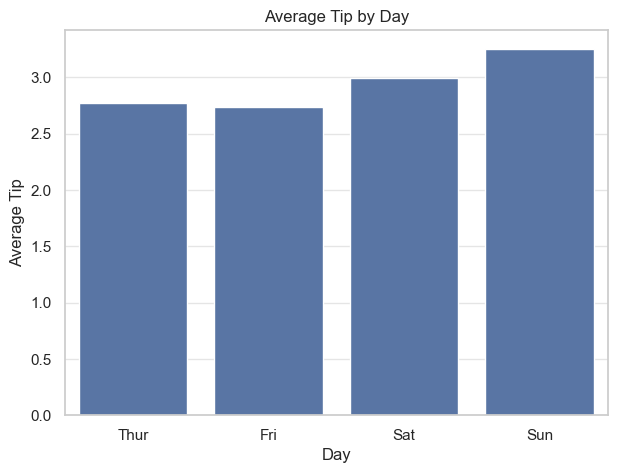

In [43]:
avg_tip_by_day = df.groupby("day", as_index=False)["tip"].mean()
display(avg_tip_by_day)

plt.figure(figsize=(7, 5))
sns.barplot(data=avg_tip_by_day, x="day", y="tip", errorbar=None)
plt.title("Average Tip by Day")
plt.xlabel("Day")
plt.ylabel("Average Tip")
plt.show()

## 31. Add a calculated column: tip percentage

**Request:** Create a new column called `tip_percent`, then analyze its distribution.

,total_bill,tip,tip_percent
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


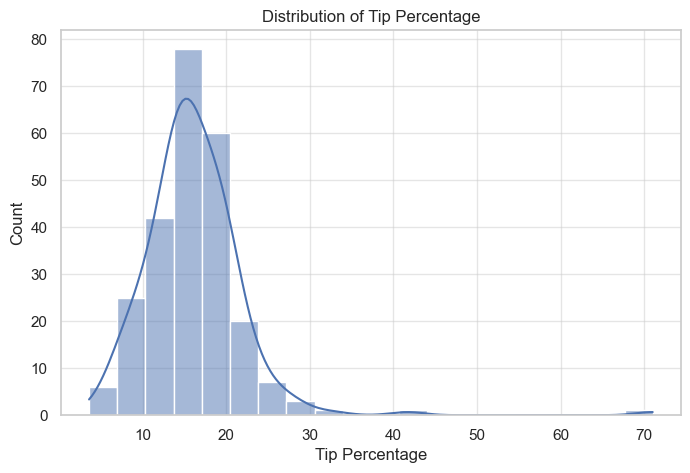

In [44]:
df["tip_percent"] = (df["tip"] / df["total_bill"]) * 100

display(df[["total_bill", "tip", "tip_percent"]].head())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tip_percent", bins=20, kde=True)
plt.title("Distribution of Tip Percentage")
plt.xlabel("Tip Percentage")
plt.ylabel("Count")
plt.show()

## 32. Compare tip percentage by smoker status

**Request:** Use a box plot to compare `tip_percent` for smokers and non-smokers.

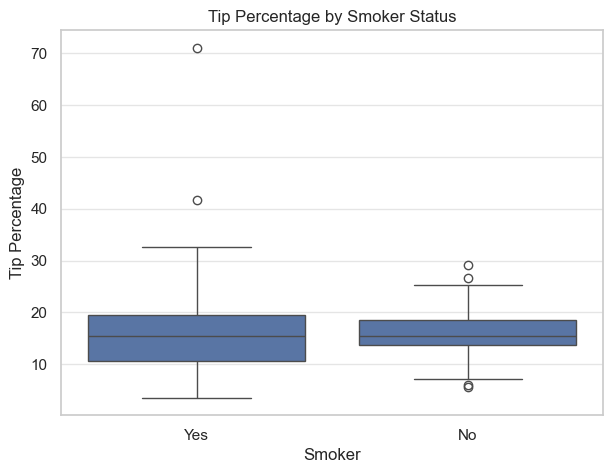

smoker
Yes    16.319604
No     15.932846
Name: tip_percent, dtype: float64


In [45]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="smoker", y="tip_percent")
plt.title("Tip Percentage by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Tip Percentage")
plt.show()

print(df.groupby("smoker")["tip_percent"].mean())

## 33. Save the final dataset

**Request:** Save the dataset with the new `tip_percent` column to an Excel file.

In [ ]:
output_file = "seaborn_tips_with_tip_percent.xlsx"
df.to_excel(output_file, index=False)
print("Saved file:", output_file)

# Summary

In this notebook, we practiced:

- Loading and exploring a dataset
- Histograms and KDE plots
- Scatter plots and regression plots
- Joint plots
- Count plots and bar plots
- Box plots, violin plots, strip plots, and swarm plots
- Pair plots and PairGrid
- Correlation heatmaps
- Pivot table heatmaps
- Styling and figure size
- Combining Pandas calculations with Seaborn visualizations